# Prescribed positive horizontal divergence

The firn density and thickness are assumed horizontally uniform, while the depth-independent horizontal velocity has constant divergence

$$
D=\nabla_h\cdot\mathbf u>0.
$$

Here “constant through the column” means independent of $\zeta$, not constant in horizontal position.

The reduced equations contain the source terms

$$
\nabla_h\cdot(h\rho\mathbf u)=h\rho D,
\qquad
\nabla_h\cdot(h\mathbf u)=hD.
$$

The run below compares $D=0$ with $D=10^{-3}\ {\rm yr}^{-1}$, keeping the Herron–Langway forcing unchanged.

In [1]:
from firedrake import *
from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.integrate import cumulative_trapezoid
from irksome import BackwardEuler, MeshConstant, TimeStepper

from firn_model import linear_compaction, run_model
from firn_model.forms import column_forms

In [2]:
rho_i_value = 917.0
rho_s_value = 300.0
rho_b_target = 830.0
a_s_value = 0.30

temperature = 243.15
gas_constant = 8.314
c_value = 11.0 * np.exp(-10160.0 / (gas_constant * temperature))
k_value = c_value * a_s_value

lambda_target = np.log(
    rho_b_target * (rho_i_value - rho_s_value)
    / (rho_s_value * (rho_i_value - rho_b_target))
)
h_target = lambda_target * rho_s_value / (c_value * rho_i_value)
a_b_value = rho_s_value * a_s_value / rho_b_target

D_value = 1.0e-3  # yr^-1

print(f"zero-divergence HL thickness = {h_target:.8f} m")
print(f"prescribed divergence        = {D_value:.3e} yr^-1")

zero-divergence HL thickness = 13.48275644 m
prescribed divergence        = 1.000e-03 yr^-1


In [14]:
n_vertical = 100

base_mesh = UnitIntervalMesh(1)
mesh = ExtrudedMesh(
    base_mesh,
    layers=n_vertical,
    layer_height=1.0 / n_vertical,
)

zeta_axis = mesh.geometric_dimension - 1
zeta = SpatialCoordinate(mesh)[zeta_axis]

V_rho = FunctionSpace(mesh, "DG", 0, vfamily="DG", vdegree=0)
V_h = FunctionSpace(mesh, "DG", 0, vfamily="R", vdegree=0)
V_p = FunctionSpace(mesh, "DG", 0, vfamily="CG", vdegree=1)
W = V_rho * V_h * V_p

rho_i = Constant(rho_i_value)
rho_s = Constant(rho_s_value)
a_s = Constant(a_s_value)
a_b = Constant(a_b_value)
c = Constant(c_value)

params = SimpleNamespace(
    rho_i=rho_i,
    rho_s=rho_s,
    a_s=a_s,
    a_b=a_b,
    c=c,
    temperature=temperature,
)

lam = c_value * h_target * rho_i_value / rho_s_value
rho_HL = (
    rho_i_value * rho_s_value
    / (
        rho_s_value
        + (rho_i_value - rho_s_value)
        * exp(-lam * (1.0 - zeta))
    )
)

In [25]:
state_zero = Function(W, name="zero_divergence")
state_div = Function(W, name="positive_divergence")

rho_zero, h_zero, p_zero = state_zero.subfunctions
rho_div, h_div, p_div = state_div.subfunctions

# Start both runs from the zero-divergence continuum steady profile.
rho_zero.interpolate(rho_HL)
h_zero.assign(h_target)
p_zero.interpolate(-rho_s * a_s / rho_HL)

state_div.assign(state_zero);

In [16]:
rho, h, p = split(state_zero)
time_zero_forms, spatial_zero_forms = column_forms(
    (rho, h, p),
    TestFunctions(W),
    params,
    compaction=linear_compaction,
    horizontal_divergence=Constant(0.0),
)
F_zero = sum(time_zero_forms.values()) + sum(spatial_zero_forms.values())

D = Constant(D_value)

rho, h, p = split(state_div)
time_div_forms, spatial_div_forms = column_forms(
    (rho, h, p),
    TestFunctions(W),
    params,
    compaction=linear_compaction,
    horizontal_divergence=D,
)
F_div = sum(time_div_forms.values()) + sum(spatial_div_forms.values())

In [17]:
solver_parameters = {
    "mat_type": "nest",
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_rtol": 1.0e-10,
    "snes_atol": 1.0e-11,
    "snes_max_it": 30,
    "ksp_type": "fgmres",
    "ksp_rtol": 1.0e-10,
    "ksp_atol": 1.0e-12,
    "ksp_max_it": 300,
    "pc_type": "fieldsplit",
    "pc_fieldsplit_type": "multiplicative",
    "fieldsplit_0_ksp_type": "preonly",
    "fieldsplit_0_pc_type": "lu",
    "fieldsplit_1_ksp_type": "preonly",
    "fieldsplit_1_pc_type": "lu",
    "fieldsplit_2_ksp_type": "gmres",
    "fieldsplit_2_ksp_rtol": 1.0e-10,
    "fieldsplit_2_pc_type": "none",
}

In [18]:
MC = MeshConstant(mesh)

time_zero = MC.Constant(0.0)
dt_zero = MC.Constant(20.0)

time_div = MC.Constant(0.0)
dt_div = MC.Constant(20.0)

bc_zero = DirichletBC(W.sub(2), -a_s, "top")
bc_div = DirichletBC(W.sub(2), -a_s, "top")

stepper_zero = TimeStepper(
    F_zero,
    BackwardEuler(),
    time_zero,
    dt_zero,
    state_zero,
    bcs=[bc_zero],
    stage_type="value",
    solver_parameters=solver_parameters,
)

stepper_div = TimeStepper(
    F_div,
    BackwardEuler(),
    time_div,
    dt_div,
    state_div,
    bcs=[bc_div],
    stage_type="value",
    solver_parameters=solver_parameters,
)

In [19]:
times_zero = [0.0]
heights_zero = [float(h_zero.dat.data_ro[0])]

times_div = [0.0]
heights_div = [float(h_div.dat.data_ro[0])]
mass_budget_errors = []

mass_old = [assemble(h_div * rho_div * dx)]

def record_zero(step, t, state):
    times_zero.append(t)
    heights_zero.append(float(h_zero.dat.data_ro[0]))

def record_div(step, t, state):
    mass_new = assemble(h_div * rho_div * dx)

    surface_flux = assemble(rho_s * p_div * ds_t)
    basal_flux = assemble(-rho_div * p_div * ds_b)
    horizontal_loss = assemble(h_div * rho_div * D * dx)

    error = (
        (mass_new - mass_old[0]) / float(dt_div)
        + surface_flux
        + basal_flux
        + horizontal_loss
    )

    times_div.append(t)
    heights_div.append(float(h_div.dat.data_ro[0]))
    mass_budget_errors.append(float(error))
    mass_old[0] = mass_new

In [20]:
final_time = 10000.0

run_model(
    stepper_zero,
    state_zero,
    time_zero,
    dt_zero,
    final_time,
    after_step=record_zero,
)

run_model(
    stepper_div,
    state_div,
    time_div,
    dt_div,
    final_time,
    after_step=record_div,
)

times_zero = np.asarray(times_zero)
heights_zero = np.asarray(heights_zero)
times_div = np.asarray(times_div)
heights_div = np.asarray(heights_div)
mass_budget_errors = np.asarray(mass_budget_errors)

## Semi-analytic steady benchmark

Let $q=-p>0$ and $k=c\,a_s$. At steady state,

$$
q(\rho)
=
a_s\frac{\rho_s}{\rho}
\left(
\frac{\rho_i-\rho}{\rho_i-\rho_s}
\right)^{D/k}.
$$

The basal density solves \(q(\rho_b)=a_b\), and the thickness is

$$
h
=
\int_{\rho_s}^{\rho_b}
\frac{q(\rho)}{k(\rho_i-\rho)}\,d\rho.
$$

For $D=0$, these reduce to the usual Herron–Langway relations.

In [21]:
def q_of_rho(rho, divergence):
    return (
        a_s_value * rho_s_value / rho
        * (
            (rho_i_value - rho)
            / (rho_i_value - rho_s_value)
        ) ** (divergence / k_value)
    )

rho_b_reference = brentq(
    lambda rho: q_of_rho(rho, D_value) - a_b_value,
    rho_s_value + 1.0e-10,
    rho_i_value - 1.0e-10,
)

rho_grid = np.linspace(rho_s_value, rho_b_reference, 20000)
integrand = (
    q_of_rho(rho_grid, D_value)
    / (k_value * (rho_i_value - rho_grid))
)

depth_integral = cumulative_trapezoid(
    integrand,
    rho_grid,
    initial=0.0,
)

h_reference = depth_integral[-1]
s_grid = depth_integral / h_reference

zeta_cells = (np.arange(n_vertical) + 0.5) / n_vertical
zeta_nodes = np.linspace(0.0, 1.0, n_vertical + 1)

rho_reference = np.interp(
    1.0 - zeta_cells,
    s_grid,
    rho_grid,
)

rho_nodes_reference = np.interp(
    1.0 - zeta_nodes,
    s_grid,
    rho_grid,
)
p_reference = -q_of_rho(rho_nodes_reference, D_value)

print(f"predicted basal density = {rho_b_reference:.8f} kg m^-3")
print(f"predicted thickness     = {h_reference:.8f} m")

predicted basal density = 775.47317015 kg m^-3
predicted thickness     = 10.65989063 m


In [22]:
rho_zero_final = rho_zero.dat.data_ro.copy()
rho_div_final = rho_div.dat.data_ro.copy()
p_div_final = p_div.dat.data_ro.copy()

print(f"numerical h, D = 0       = {heights_zero[-1]:.8f} m")
print(f"numerical h, D > 0       = {heights_div[-1]:.8f} m")
print(f"semi-analytic h, D > 0   = {h_reference:.8f} m")
print(f"max mass-budget residual = {np.max(np.abs(mass_budget_errors)):.3e}")

rho_rms_error = np.sqrt(np.mean((rho_div_final - rho_reference) ** 2))
print(f"RMS density error        = {rho_rms_error:.3e} kg m^-3")

assert heights_div[-1] < heights_zero[-1]
assert rho_div_final[0] < rho_zero_final[0]

numerical h, D = 0       = 13.68542648 m
numerical h, D > 0       = 10.76261069 m
semi-analytic h, D > 0   = 10.65989063 m
max mass-budget residual = 4.130e-12
RMS density error        = 1.929e+00 kg m^-3


In [23]:
rho_before = rho_div.dat.data_ro.copy()
h_before = float(h_div.dat.data_ro[0])
p_before = p_div.dat.data_ro.copy()

stepper_div.advance()

rho_rate = np.max(np.abs(rho_div.dat.data_ro - rho_before)) / float(dt_div)
h_rate = abs(float(h_div.dat.data_ro[0]) - h_before) / float(dt_div)
p_rate = np.max(np.abs(p_div.dat.data_ro - p_before)) / float(dt_div)

print(f"max |d rho / dt| = {rho_rate:.3e} kg m^-3 yr^-1")
print(f"|d h / dt|       = {h_rate:.3e} m yr^-1")
print(f"max |d p / dt|   = {p_rate:.3e} m yr^-2")

max |d rho / dt| = 0.000e+00 kg m^-3 yr^-1
|d h / dt|       = 0.000e+00 m yr^-1
max |d p / dt|   = 0.000e+00 m yr^-2


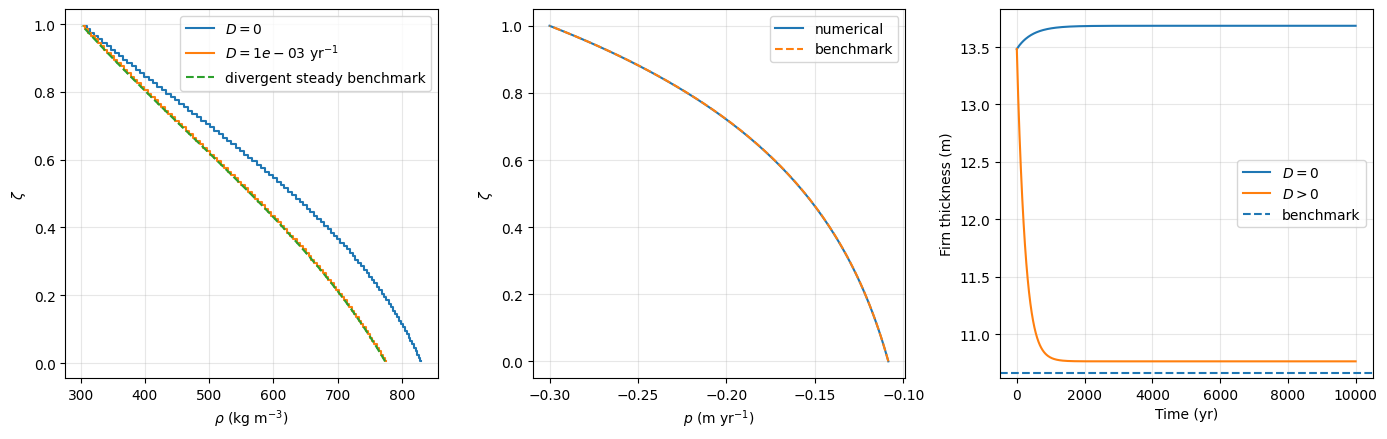

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].step(
    rho_zero_final,
    zeta_cells,
    where="mid",
    label=r"$D=0$",
)
axes[0].step(
    rho_div_final,
    zeta_cells,
    where="mid",
    label=fr"$D={D_value:.0e}\ \mathrm{{yr}}^{{-1}}$",
)
axes[0].plot(
    rho_reference,
    zeta_cells,
    "--",
    label="divergent steady benchmark",
)
axes[0].set_xlabel(r"$\rho$ (kg m$^{-3}$)")
axes[0].set_ylabel(r"$\zeta$")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(p_div_final, zeta_nodes, label="numerical")
axes[1].plot(p_reference, zeta_nodes, "--", label="benchmark")
axes[1].set_xlabel(r"$p$ (m yr$^{-1}$)")
axes[1].set_ylabel(r"$\zeta$")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(times_zero, heights_zero, label=r"$D=0$")
axes[2].plot(times_div, heights_div, label=r"$D>0$")
axes[2].axhline(h_reference, linestyle="--", label="benchmark")
axes[2].set_xlabel("Time (yr)")
axes[2].set_ylabel("Firn thickness (m)")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()